# Full Results Explainer

This notebook explains the current thesis results in detail. It is the notebook version of the long-form results explainer and is meant to help you understand:

- what each reported number means,
- why the number is roughly what it is,
- what the number allows you to claim in the thesis,
- and what is still missing.

Current result coverage:

- human benchmark under the local pipeline,
- human pairwise comparison,
- prompt-selection pilot,
- visual summaries of the ranking.

The full `LLM vs human` analysis for the selected prompt condition is still pending, so this notebook explains the current benchmark and prompt-pilot outputs and marks the missing part clearly.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

BASE = Path('..').resolve()
OUTPUTS = BASE / 'outputs'

text_summary = pd.read_csv(OUTPUTS / 'human_baseline_summaries' / 'text_metric_summary.csv')
pairwise_summary = pd.read_csv(OUTPUTS / 'human_baseline_summaries' / 'pairwise_summary.csv')
pilot_ranked = pd.read_csv(OUTPUTS / 'pilot_ranking_local' / 'pilot_condition_ranked.csv')

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

## 1. Source Files

This notebook reads from the following files:

- `outputs/human_baseline_summaries/text_metric_summary.csv`
- `outputs/human_baseline_summaries/pairwise_summary.csv`
- `outputs/pilot_ranking_local/pilot_condition_ranked.csv`

The figures used below come from:

- `outputs/presentation_figures/human_benchmark_profile.png`
- `outputs/appendix_figures/prompt_score_heatmap.png`
- `outputs/presentation_figures/top5_prompt_conditions.png`
- `outputs/presentation_figures/prompt_component_breakdown.png`


In [2]:
display(text_summary)
display(pairwise_summary)
display(pilot_ranked.head(9))

,source_type,level,variant,aoa_count,aoa_mean,aoa_std,aoa_median,concreteness_count,concreteness_mean,concreteness_std,concreteness_median,imageability_count,imageability_mean,imageability_std,imageability_median,fk_grade_count,fk_grade_mean,fk_grade_std,fk_grade_median,mtld_count,mtld_mean,mtld_std,mtld_median,cli_count,cli_mean,cli_std,cli_median,tier2_proxy_token_ratio_count,tier2_proxy_token_ratio_mean,tier2_proxy_token_ratio_std,tier2_proxy_token_ratio_median
0,human_reference,Advanced,human::advanced,189,359.450,28.504,361.404,189,355.626,16.527,354.315,189,383.006,15.703,382.589,189,11.131,1.922,11.005,189,110.285,22.683,109.463,189,-0.117,0.761,-0.145,189,0.096,0.040,0.092
1,human_reference,Elementary,human::elementary,189,340.944,31.636,340.818,189,355.620,19.185,352.708,189,383.269,18.302,381.939,189,8.156,1.397,8.071,189,83.927,15.882,83.294,189,0.185,0.885,0.112,189,0.069,0.034,0.065
2,human_reference,Intermediate,human::intermediate,189,355.029,30.063,355.460,189,354.853,17.532,352.385,189,382.183,16.412,380.385,189,9.843,1.639,9.640,189,99.837,19.196,99.078,189,-0.069,0.804,-0.053,189,0.088,0.039,0.084


,comparison_type,variant,semantic_similarity_sbert_count,semantic_similarity_sbert_mean,semantic_similarity_sbert_std,semantic_similarity_sbert_median,delta_cli_count,delta_cli_mean,delta_cli_std,delta_cli_median,delta_aoa_count,delta_aoa_mean,delta_aoa_std,delta_aoa_median,delta_concreteness_count,delta_concreteness_mean,delta_concreteness_std,delta_concreteness_median,delta_imageability_count,delta_imageability_mean,delta_imageability_std,delta_imageability_median,delta_fk_grade_count,delta_fk_grade_mean,delta_fk_grade_std,delta_fk_grade_median,delta_mtld_count,delta_mtld_mean,delta_mtld_std,delta_mtld_median,delta_tier2_proxy_token_ratio_count,delta_tier2_proxy_token_ratio_mean,delta_tier2_proxy_token_ratio_std,delta_tier2_proxy_token_ratio_median
0,human_reference,human::elementary,189,0.891,0.053,0.901,189,0.302,0.369,0.308,189,-18.507,16.523,-18.022,189,-0.006,7.962,0.397,189,0.263,7.601,0.634,189,-2.976,1.204,-2.761,189,-26.358,17.191,-24.284,189,-0.027,0.019,-0.025


,provider,model,strategy,temperature,variant,rows,json_success_rate,fk_grade_mean,fk_grade_std,aoa,concreteness,imageability,fk_grade,mtld,cli,tier2_proxy_token_ratio,human_benchmark_distance,human_benchmark_score,semantic_similarity_sbert,delta_cli,delta_aoa,delta_concreteness,delta_imageability,delta_fk_grade,delta_mtld,delta_tier2_proxy_token_ratio,stability_score,overall_score
0,openai,openai/gpt-5.2,zero_shot,0.500,openai::openai/gpt-5.2::zero_shot::temp=0.5,12,1.000,6.611,1.218,319.030,366.843,394.276,6.611,98.890,0.146,0.058,0.209,0.827,0.910,0.480,-20.857,3.337,4.773,-3.316,-16.140,-0.021,0.451,0.797
1,openai,openai/gpt-5.2,few_shot,0.200,openai::openai/gpt-5.2::few_shot::temp=0.2,12,1.000,6.498,1.194,319.862,365.443,392.945,6.498,104.094,0.080,0.057,0.230,0.813,0.911,0.414,-20.025,1.937,3.442,-3.429,-10.936,-0.022,0.456,0.795
2,openai,openai/gpt-5.2,chain_of_thought,0.200,openai::openai/gpt-5.2::chain_of_thought::temp...,12,1.000,6.397,1.302,319.062,365.400,392.135,6.397,99.916,0.075,0.057,0.228,0.814,0.927,0.409,-20.825,1.895,2.632,-3.530,-15.114,-0.022,0.434,0.794
3,openai,openai/gpt-5.2,zero_shot,0.200,openai::openai/gpt-5.2::zero_shot::temp=0.2,12,1.000,6.543,1.240,316.963,364.607,391.544,6.543,101.516,0.081,0.053,0.254,0.797,0.914,0.415,-22.925,1.101,2.041,-3.384,-13.514,-0.025,0.446,0.789
4,openai,openai/gpt-5.2,zero_shot,0.000,openai::openai/gpt-5.2::zero_shot::temp=0.0,12,1.000,6.736,1.331,316.984,363.977,391.565,6.736,103.991,0.069,0.055,0.252,0.799,0.924,0.404,-22.904,0.472,2.062,-3.191,-11.039,-0.024,0.429,0.788
5,openai,openai/gpt-5.2,few_shot,0.000,openai::openai/gpt-5.2::few_shot::temp=0.0,12,1.000,6.678,1.452,319.045,364.767,391.777,6.678,101.469,0.056,0.056,0.222,0.819,0.916,0.391,-20.843,1.261,2.274,-3.249,-13.561,-0.023,0.408,0.786
6,openai,openai/gpt-5.2,few_shot,0.500,openai::openai/gpt-5.2::few_shot::temp=0.5,12,1.000,6.676,1.511,316.934,364.536,391.866,6.676,101.687,0.086,0.054,0.235,0.810,0.912,0.421,-22.953,1.030,2.363,-3.251,-13.343,-0.024,0.398,0.780
7,openai,openai/gpt-5.2,chain_of_thought,0.500,openai::openai/gpt-5.2::chain_of_thought::temp...,12,1.000,6.465,1.651,320.575,364.031,390.676,6.465,102.103,-0.003,0.056,0.270,0.787,0.927,0.331,-19.312,0.526,1.173,-3.462,-12.927,-0.022,0.377,0.773
8,openai,openai/gpt-5.2,chain_of_thought,0.000,openai::openai/gpt-5.2::chain_of_thought::temp...,12,1.000,6.545,1.520,323.003,363.375,390.585,6.545,105.711,-0.054,0.053,0.318,0.759,0.921,0.280,-16.885,-0.131,1.082,-3.382,-9.319,-0.025,0.397,0.769


## 2. How To Read the Summary Statistics

The main summary columns mean:

- `count`: how many texts contributed to the value.
- `mean`: the average across texts.
- `std`: the standard deviation, which shows how much the texts vary.
- `median`: the middle value after sorting.

Interpretation logic:

- the `mean` tells you the central tendency,
- the `std` tells you how stable or variable that tendency is,
- the `median` helps check whether the mean may be influenced by extreme values.

For the human benchmark, the key count is `189`, because there are `189` aligned source stories in the benchmark used here.


## 3. Human Benchmark Results

The human benchmark is the main reference for the thesis.

- `Advanced` = original/source text
- `Elementary` = human simplification
- `Intermediate` = available in the corpus, but secondary in the main thesis comparison

The point of this section is to identify the numerical pattern of successful human simplification under the local pipeline.


In [3]:
benchmark_table = text_summary[['level','aoa_mean','concreteness_mean','imageability_mean','fk_grade_mean','mtld_mean','cli_mean','tier2_proxy_token_ratio_mean']].copy()
benchmark_table.columns = ['Level','AoA Mean','Concreteness Mean','Imageability Mean','FKGL Mean','MTLD Mean','CLI Mean','Tier 2 Proxy Mean']
display(benchmark_table)

,Level,AoA Mean,Concreteness Mean,Imageability Mean,FKGL Mean,MTLD Mean,CLI Mean,Tier 2 Proxy Mean
0,Advanced,359.450,355.626,383.006,11.131,110.285,-0.117,0.096
1,Elementary,340.944,355.620,383.269,8.156,83.927,0.185,0.069
2,Intermediate,355.029,354.853,382.183,9.843,99.837,-0.069,0.088


### Human Benchmark Figure

This figure is useful because it compresses the main benchmark signal into one visual profile.


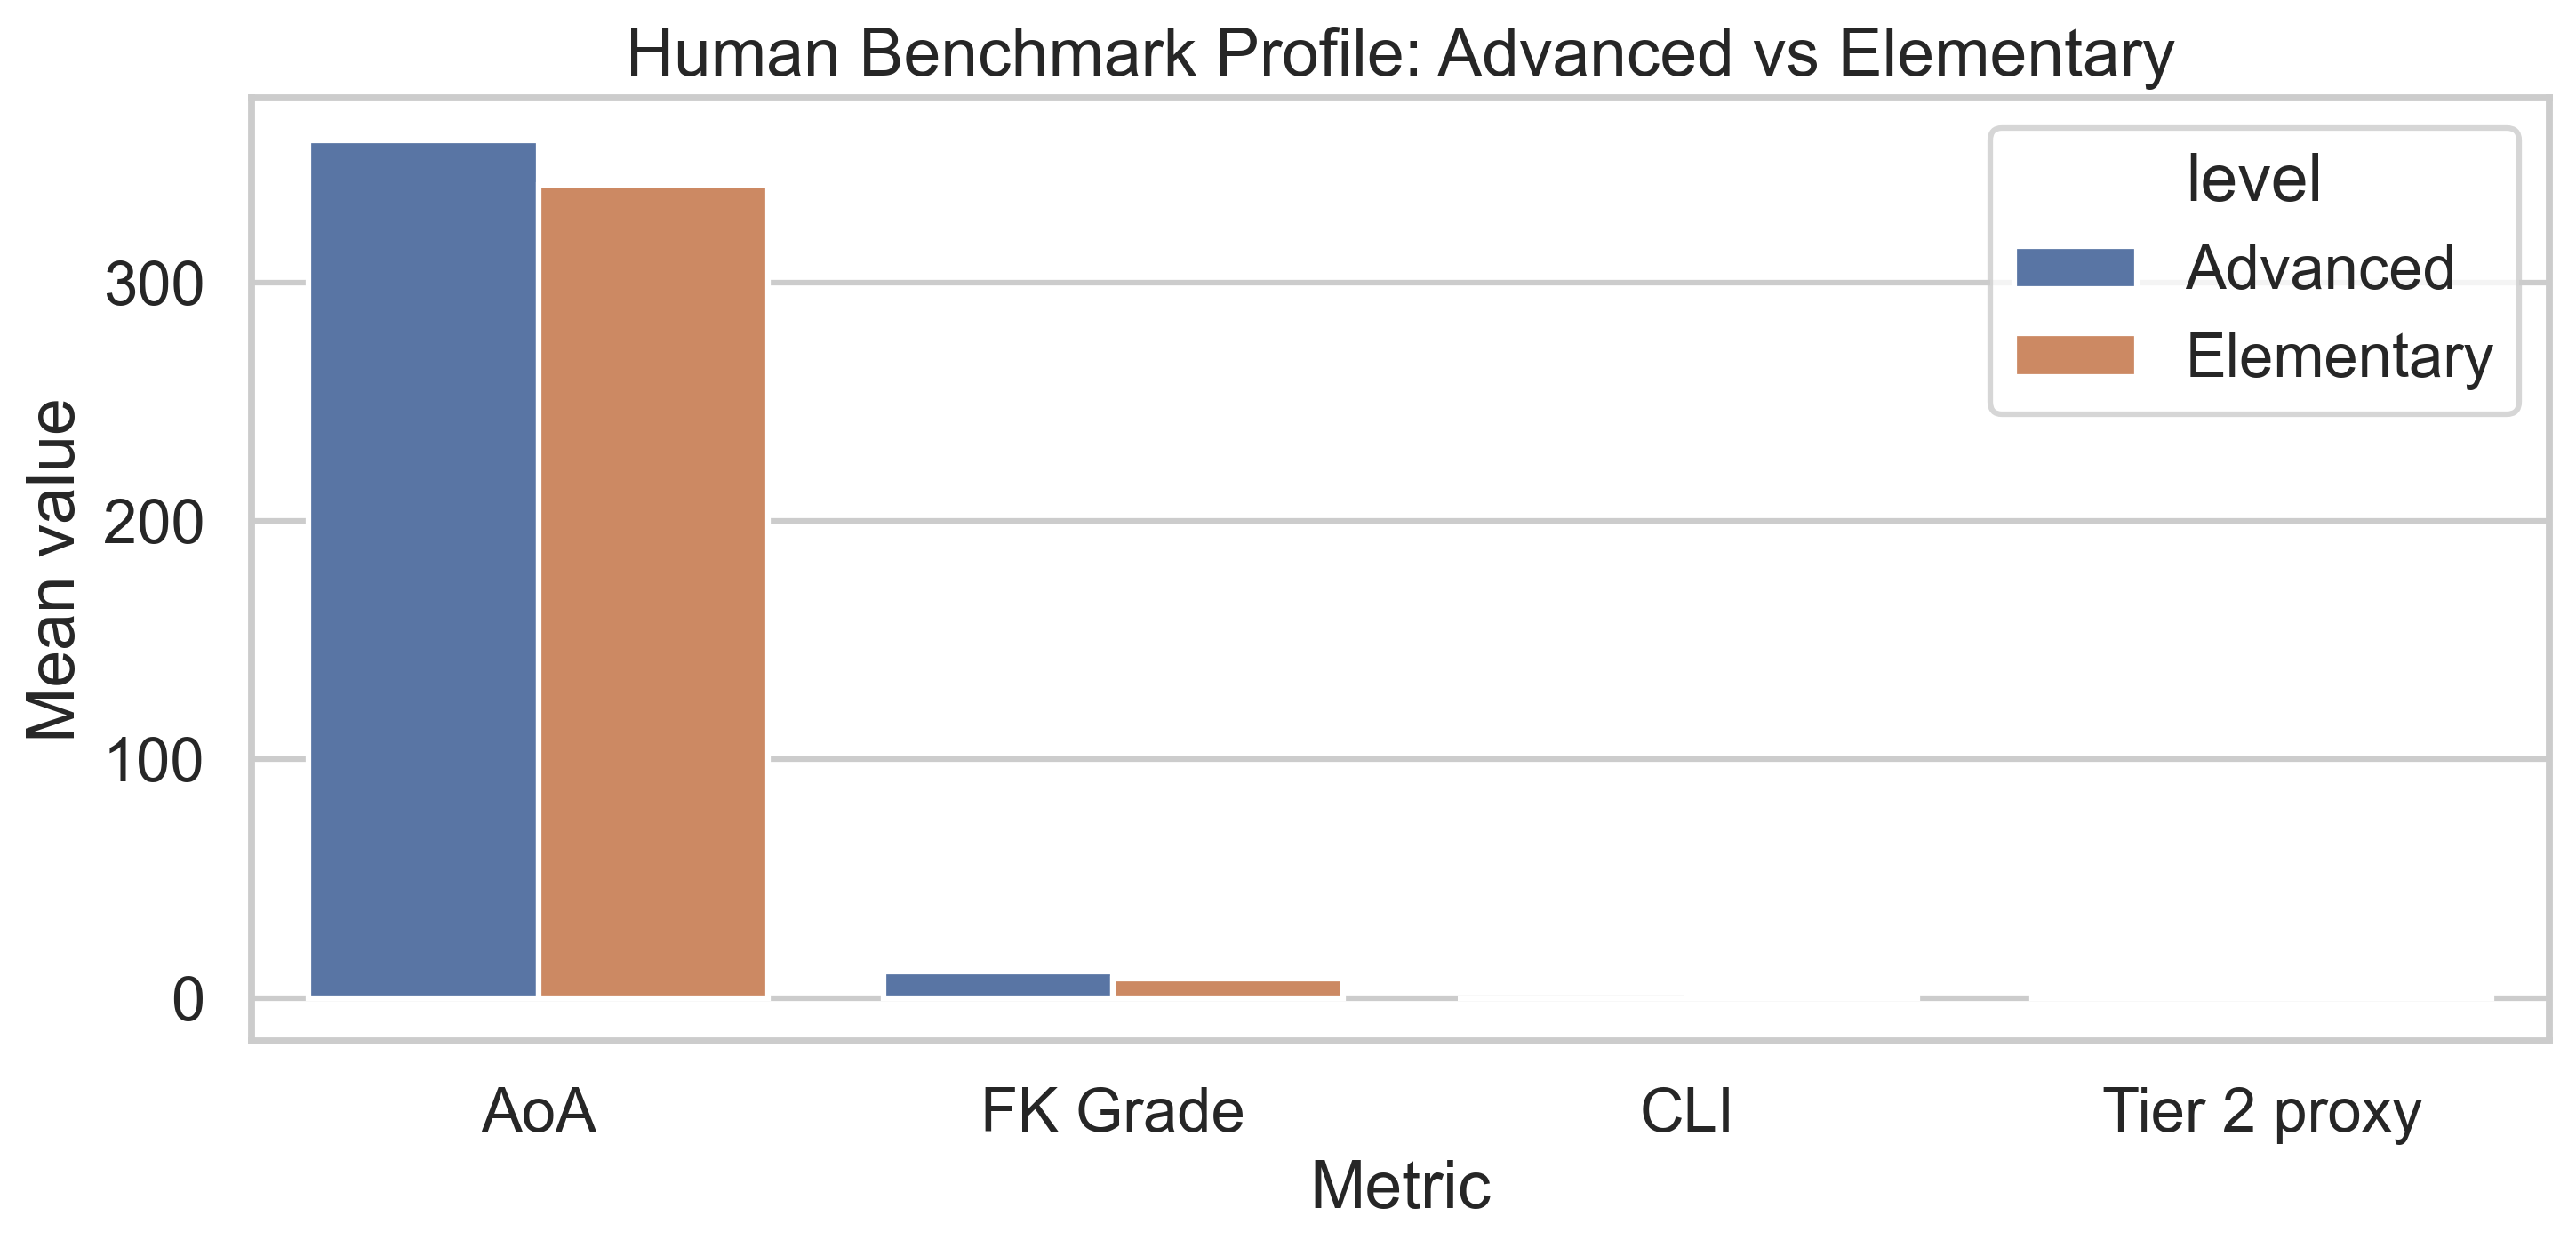

In [4]:
display(Image(filename=str(OUTPUTS / 'presentation_figures' / 'human_benchmark_profile.png')))

### 3.1 Metric-by-Metric Interpretation

#### Age of Acquisition

- Advanced mean: `359.45`
- Elementary mean: `340.94`

Meaning:

The Elementary texts use vocabulary associated with earlier acquisition. This supports the claim that human simplification reduces lexical difficulty.

Why the number likely looks like this:

Human simplifiers replace or avoid later-acquired vocabulary in order to improve accessibility.

Thesis meaning:

This is strong evidence that `AoA` behaves as a valid accessibility signal in the benchmark.

#### Concreteness

- Advanced mean: `355.63`
- Elementary mean: `355.62`

Meaning:

There is almost no average change in concreteness.

Why the number likely looks like this:

The corpus seems to simplify more through structural and lexical-difficulty changes than through making content more concrete.

Thesis meaning:

Concreteness is useful as a control variable, but not the main driver of the benchmark difference.

#### Imageability

- Advanced mean: `383.01`
- Elementary mean: `383.27`

Meaning:

Imageability increases slightly in the human simplified texts.

Why the number likely looks like this:

Some rewrites may make the language slightly easier to picture, but the underlying educational content remains similar.

Thesis meaning:

Imageability contributes nuance, but the effect is modest.

#### Flesch-Kincaid Grade Level

- Advanced mean: `11.13`
- Elementary mean: `8.16`

Meaning:

The human simplified texts are structurally much easier to read.

Why the number likely looks like this:

Simplification reduces sentence complexity and lexical burden.

Thesis meaning:

This validates that the benchmark is a real simplification benchmark and not just a relabeling of similar texts.

#### Measure of Textual Lexical Diversity

- Advanced mean: `110.29`
- Elementary mean: `83.93`

Meaning:

The human simplified texts use less varied vocabulary.

Why the number likely looks like this:

Simpler texts tend to reuse easier vocabulary rather than maintaining a wide lexical range.

Thesis meaning:

This supports the idea that simplification reduces lexical diversity, but does not by itself decide educational value.

#### Composite Lexical Index

- Advanced mean: `-0.12`
- Elementary mean: `0.19`

Meaning:

The human simplified texts are more accessible on the combined psycholinguistic index.

Why the number likely looks like this:

The index is driven especially by the lower `AoA` values in the simplified texts.

Thesis meaning:

The composite index behaves in the intended direction and is useful as a summary accessibility signal.

Why the Advanced mean is negative:

The `CLI` subtracts standardized `AoA` in the formula, because later-acquired vocabulary should lower accessibility. The Advanced texts have above-average `AoA`, so the negative `AoA` term pulls their composite score downward. A negative `CLI` therefore does not mean the text is wrong or bad; it means the text is below the dataset average on the accessibility-oriented composite index.

#### Tier 2 Proxy

- Advanced mean: `0.096`
- Elementary mean: `0.069`

Meaning:

The human simplified texts retain a smaller proportion of `Academic Vocabulary List` matched lexical tokens.

Why the number likely looks like this:

Simplification removes some academic or growth-oriented vocabulary in order to make the text easier.

Thesis meaning:

This is one of the most important benchmark findings: some loss of growth vocabulary is normal even in successful human simplification.


## 4. Human Pairwise Comparison

The pairwise table is stronger than just comparing overall means because each Elementary text is compared directly to its aligned Advanced source.

Sign rule:

- negative delta = the simplified text is lower on that metric
- positive delta = the simplified text is higher on that metric


In [5]:
pairwise_table = pairwise_summary[['semantic_similarity_sbert_mean','delta_cli_mean','delta_aoa_mean','delta_concreteness_mean','delta_imageability_mean','delta_fk_grade_mean','delta_mtld_mean','delta_tier2_proxy_token_ratio_mean']].copy()
pairwise_table.columns = ['SBERT Mean','Delta CLI','Delta AoA','Delta Concreteness','Delta Imageability','Delta FKGL','Delta MTLD','Delta Tier 2 Proxy']
display(pairwise_table)

,SBERT Mean,Delta CLI,Delta AoA,Delta Concreteness,Delta Imageability,Delta FKGL,Delta MTLD,Delta Tier 2 Proxy
0,0.891,0.302,-18.507,-0.006,0.263,-2.976,-26.358,-0.027


### 4.1 What the Pairwise Numbers Mean

#### SBERT Mean = `0.891`

Meaning:

The human simplified texts stay very close in meaning to the source texts.

Thesis meaning:

This is the semantic-preservation target range that LLM outputs should try to approach.

#### Delta AoA = `-18.507`

Meaning:

The simplified text uses earlier-acquired vocabulary than the source text.

Thesis meaning:

The local pipeline captures the expected accessibility shift in a very direct way.

#### Delta Concreteness = `-0.006`

Meaning:

Concreteness hardly changes at all on average.

Thesis meaning:

If an LLM later changes concreteness dramatically, that would be a deviation from the human pattern.

#### Delta Imageability = `0.263`

Meaning:

Imageability increases slightly.

Thesis meaning:

Small positive movement is compatible with human-like simplification, but imageability is not the main benchmark driver.

#### Delta FKGL = `-2.976`

Meaning:

The human simplified texts are about three grade levels easier.

Thesis meaning:

LLMs should reduce readability difficulty too, but if they reduce it much more aggressively than the human benchmark while harming semantics or the Tier 2 proxy, that would suggest oversimplification.

#### Delta MTLD = `-26.358`

Meaning:

Lexical diversity drops strongly.

Thesis meaning:

This confirms that simplification reduces lexical variety, but `MTLD` remains a secondary control metric in this thesis.

#### Delta CLI = `0.302`

Meaning:

The simplified texts become more accessible on the combined psycholinguistic index.

Thesis meaning:

This gives you one compact accessibility target for later LLM comparison.

#### Delta Tier 2 Proxy = `-0.027`

Meaning:

The human simplified texts contain about `2.7` percentage points less AVL-matched academic vocabulary.

Thesis meaning:

This is crucial: a moderate drop in growth vocabulary is compatible with successful simplification. The LLM should therefore be judged by how closely it matches the human level of reduction, not by whether the value drops at all.


## 5. Prompt-Selection Pilot

The pilot does not answer the final thesis comparison yet. Its purpose is narrower: choose the most defensible prompt strategy and temperature for the full LLM run.

Pilot design:

- `12` Advanced texts
- `3` strategies: `zero_shot`, `few_shot`, `chain_of_thought`
- `3` temperatures: `0.0`, `0.2`, `0.5`
- total: `108` generations


In [6]:
pilot_view = pilot_ranked[['strategy','temperature','json_success_rate','fk_grade_mean','fk_grade_std','stability_score','semantic_similarity_sbert','human_benchmark_score','overall_score']].copy()
pilot_view.columns = ['Strategy','Temp','JSON Success','FK Mean','FK Std','Stability Score','SBERT','Benchmark Score','Overall Score']
display(pilot_view.head(9))

,Strategy,Temp,JSON Success,FK Mean,FK Std,Stability Score,SBERT,Benchmark Score,Overall Score
0,zero_shot,0.500,1.000,6.611,1.218,0.451,0.910,0.827,0.797
1,few_shot,0.200,1.000,6.498,1.194,0.456,0.911,0.813,0.795
2,chain_of_thought,0.200,1.000,6.397,1.302,0.434,0.927,0.814,0.794
3,zero_shot,0.200,1.000,6.543,1.240,0.446,0.914,0.797,0.789
4,zero_shot,0.000,1.000,6.736,1.331,0.429,0.924,0.799,0.788
5,few_shot,0.000,1.000,6.678,1.452,0.408,0.916,0.819,0.786
6,few_shot,0.500,1.000,6.676,1.511,0.398,0.912,0.810,0.780
7,chain_of_thought,0.500,1.000,6.465,1.651,0.377,0.927,0.787,0.773
8,chain_of_thought,0.000,1.000,6.545,1.520,0.397,0.921,0.759,0.769


### Prompt-Ranking Figures

These figures help explain not just which condition won, but why it won.


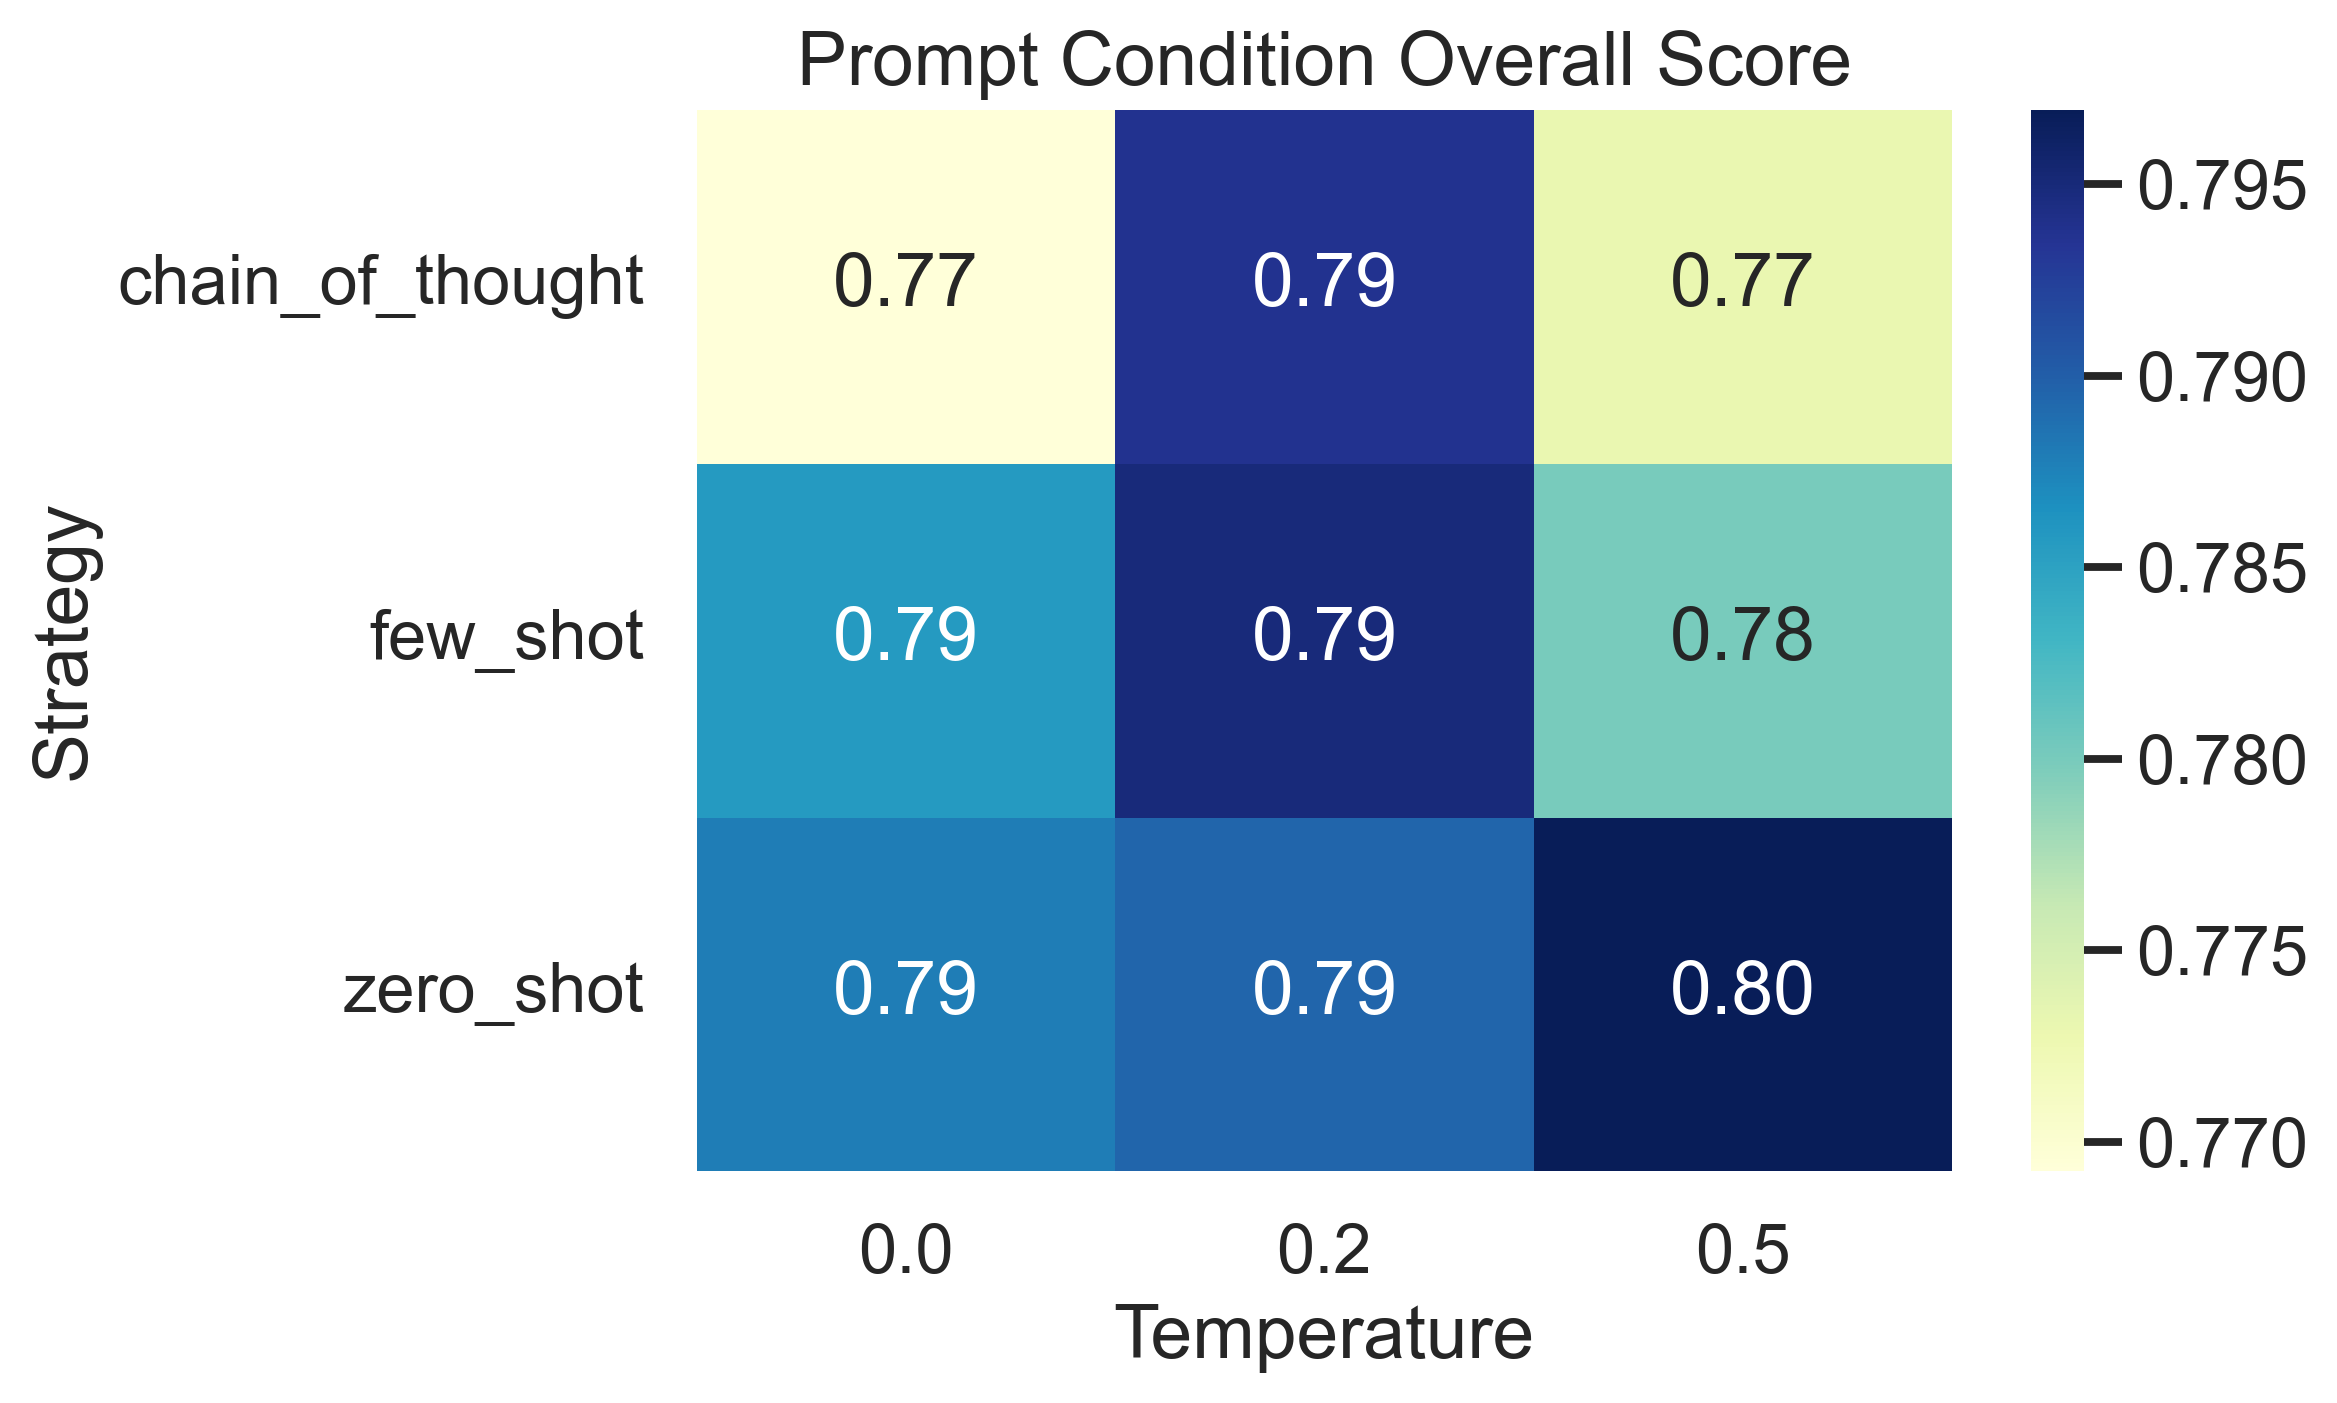

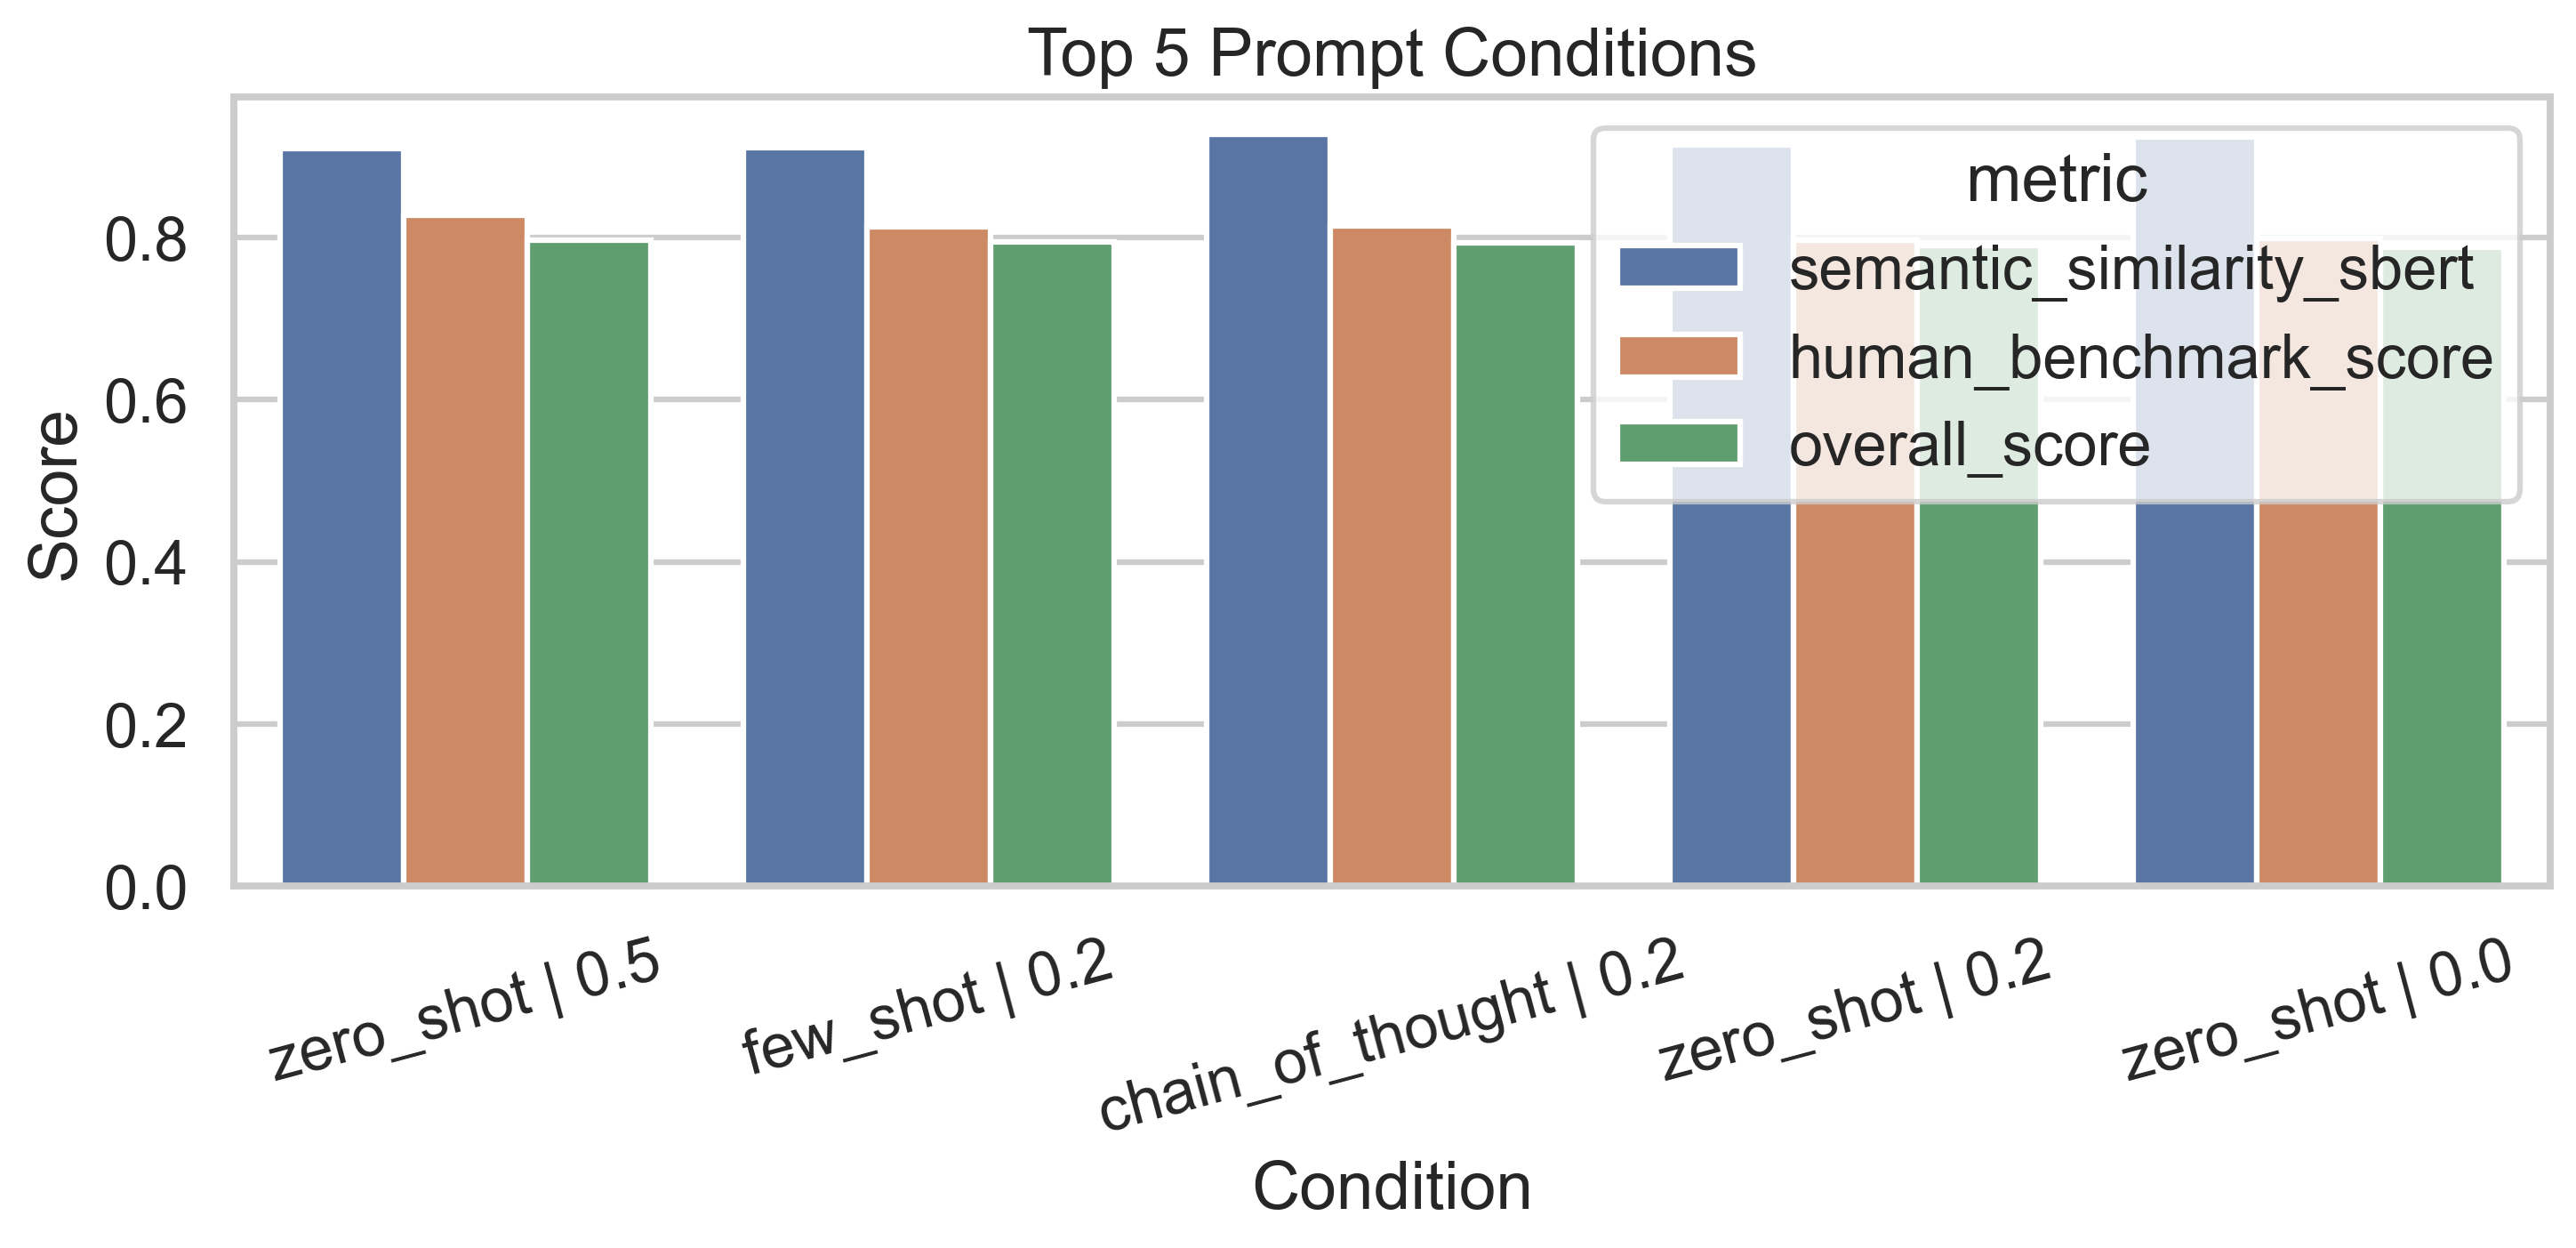

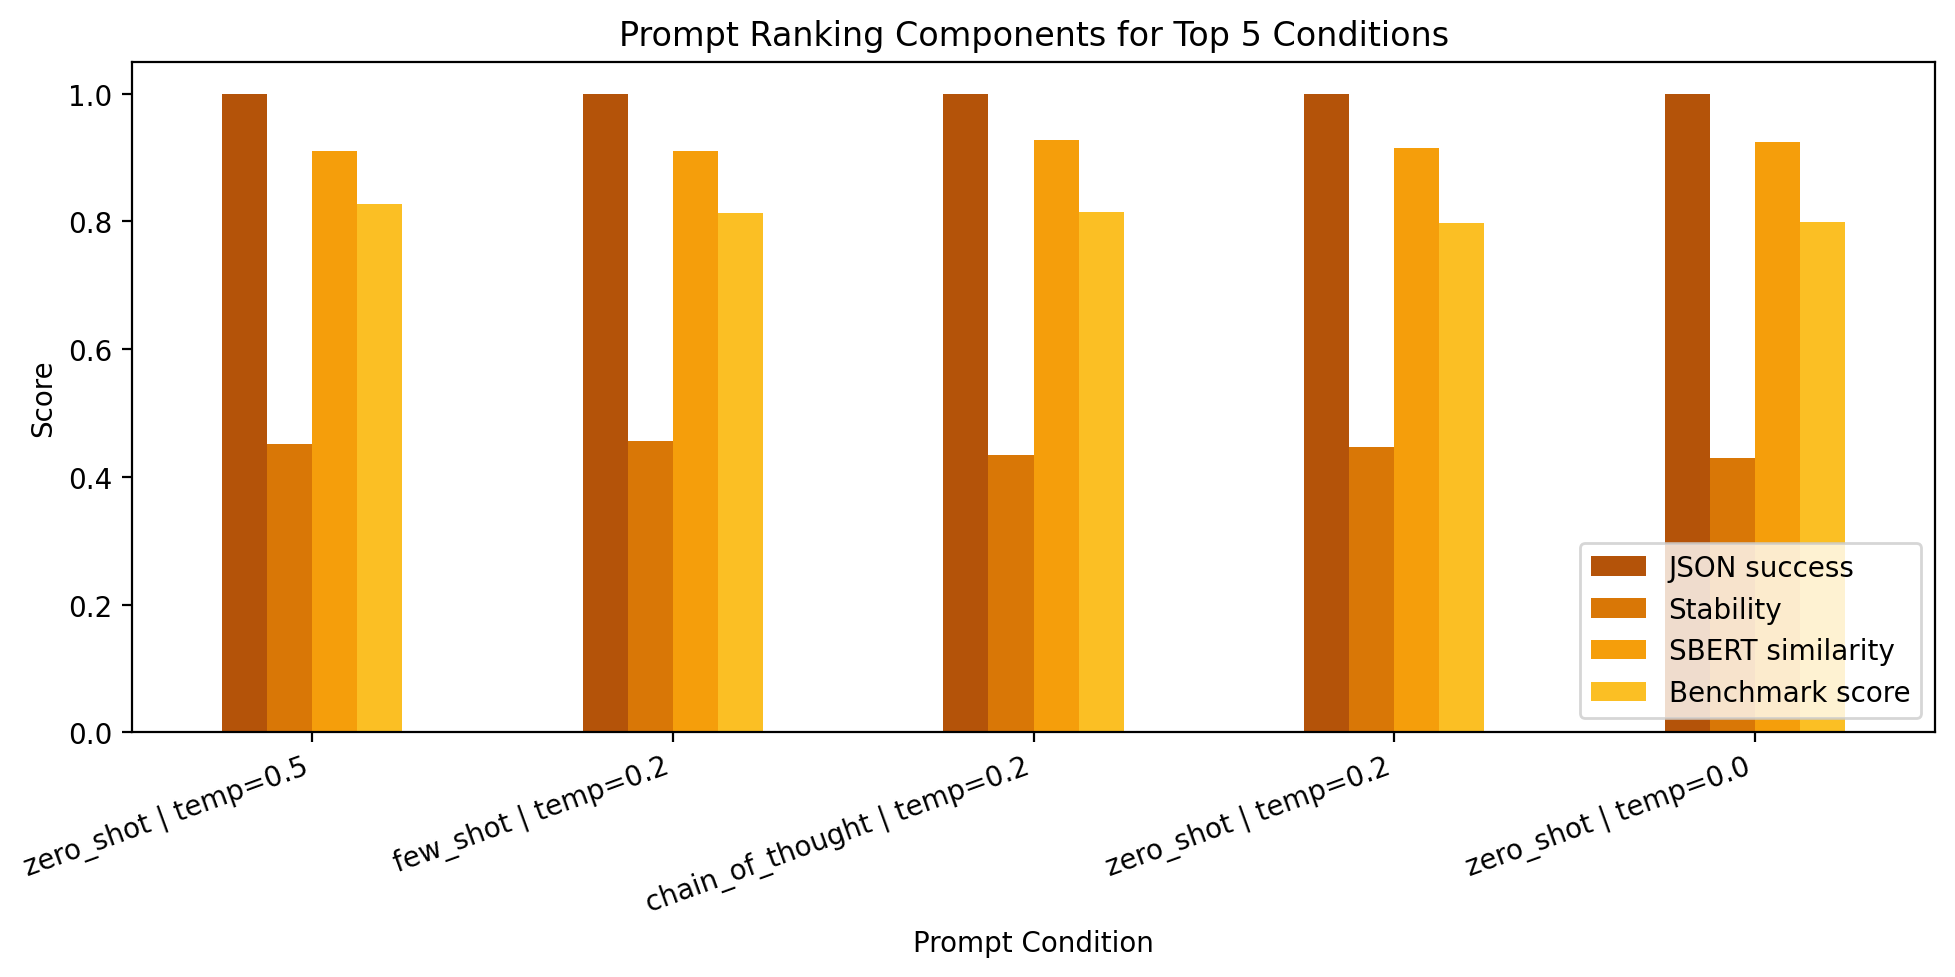

In [7]:
display(Image(filename=str(OUTPUTS / 'appendix_figures' / 'prompt_score_heatmap.png')))
display(Image(filename=str(OUTPUTS / 'presentation_figures' / 'top5_prompt_conditions.png')))
display(Image(filename=str(OUTPUTS / 'presentation_figures' / 'prompt_component_breakdown.png')))

### 5.1 How to Read the Prompt-Ranking Numbers

#### JSON Success Rate

All nine pilot conditions have `1.000`.

Meaning:

Every tested condition returned usable structured output for all 12 texts.

Thesis meaning:

The prompt choice is not being driven by reliability differences. It is being driven by quality differences.

#### FK Mean

Examples:

- `zero_shot 0.5 = 6.611`
- `chain_of_thought 0.2 = 6.397`

Meaning:

All prompt conditions simplify strongly, even more aggressively on average than the human Elementary benchmark, whose mean `FKGL` is `8.156`.

Thesis meaning:

Readability reduction alone is not enough to choose the best condition. A very low readability score can still reflect over-simplification.

#### FK Std and Stability Score

The stability score is computed as:

`1 / (1 + FK std)`

Meaning:

Lower FK variability across the 12 texts gives a higher score.

Thesis meaning:

A condition is rewarded for being consistent, not just occasionally impressive.

#### SBERT Similarity

Examples:

- `zero_shot 0.5 = 0.910`
- `few_shot 0.2 = 0.911`
- `chain_of_thought 0.2 = 0.927`

Meaning:

All top conditions preserve meaning fairly well, with `chain_of_thought 0.2` strongest on this dimension.

Thesis meaning:

Semantic preservation matters, but it is not the only decision criterion.

#### Human Benchmark Score

Examples:

- `zero_shot 0.5 = 0.827`
- `few_shot 0.2 = 0.813`
- `chain_of_thought 0.2 = 0.814`

Meaning:

`zero_shot 0.5` is the closest overall match to the human Elementary benchmark among the tested conditions.

Why the score matters:

It summarizes closeness to the human benchmark across `AoA`, `Concreteness`, `Imageability`, `FKGL`, `MTLD`, `CLI`, and the `Tier 2 proxy`.

#### Overall Score

Examples:

- `zero_shot 0.5 = 0.797`
- `few_shot 0.2 = 0.795`
- `chain_of_thought 0.2 = 0.794`

Meaning:

`zero_shot 0.5` is the best-scoring condition under the current ranking method, but the margins are very small.

Thesis meaning:

The selected setting is a practical best condition, not a dramatic landslide winner.


## 6. Why Zero-Shot at Temperature 0.5 Won

This is the clearest short explanation:

- all conditions were equally reliable,
- `chain_of_thought 0.2` was strongest on semantic similarity,
- `few_shot 0.2` was strongest on stability,
- `zero_shot 0.5` had the best overall balance across all ranking components.

That is why it was selected.

The important thesis point is that the prompt choice was not made by intuition. It was made by a transparent ranking rule tied to the human benchmark.


## 7. What Is Still Missing

The main missing result set is the final `LLM vs human` comparison on the full corpus using the selected prompt condition.

So the thesis can already claim:

- the human benchmark is established,
- the local pipeline works,
- the prompt pilot is complete,
- a defensible prompt setting has been selected.

But it cannot yet fully claim:

- how the final selected LLM setup compares with the human benchmark on the complete evaluation,
- whether the full selected model behaves consistently across the entire dataset.


## 8. Short Verbal Summary

Use this if you need a compact explanation:

`The human benchmark shows that successful simplification lowers readability difficulty and Age of Acquisition, but also reduces the Tier 2 proxy and lexical diversity somewhat. That means accessibility improves, but some growth vocabulary is lost even in human simplification. The prompt pilot then tested nine LLM settings and selected zero-shot at temperature 0.5 because it had the best overall balance of stability, semantic preservation, and closeness to the human Elementary benchmark. The full LLM-versus-human comparison is still the main missing result.`


## Prompt Pilot Run 2 and Run Comparison

This section keeps the original pilot results intact and adds the rerun carried out after replacing the few-shot examples with sourced ASSET examples.
The tables below show `Run 2` separately and then compare `Run 1` against `Run 2`.


In [8]:
run1_ranked = pd.read_csv(OUTPUTS / 'pilot_ranking_local' / 'pilot_condition_ranked.csv')
run2_ranked = pd.read_csv(OUTPUTS / 'pilot_ranking_run2' / 'pilot_condition_ranked.csv')
run_compare = pd.read_csv(OUTPUTS / 'pilot_run_comparison.csv')
display(run2_ranked[['strategy','temperature','json_success_rate','fk_grade_mean','fk_grade_std','stability_score','semantic_similarity_sbert','human_benchmark_score','overall_score']].head(9).round(3))
display(run_compare[['strategy','temperature','rank_run1','rank_run2','delta_rank','overall_score_run1','overall_score_run2','delta_overall_score','delta_semantic_similarity_sbert','delta_human_benchmark_score']].sort_values(['rank_run2','rank_run1']).round(3))


,strategy,temperature,json_success_rate,fk_grade_mean,fk_grade_std,stability_score,semantic_similarity_sbert,human_benchmark_score,overall_score
0,zero_shot,0.200,1.000,6.538,1.248,0.445,0.916,0.831,0.798
1,zero_shot,0.000,1.000,6.333,1.140,0.467,0.913,0.808,0.797
2,few_shot,0.500,1.000,6.169,1.258,0.443,0.917,0.810,0.792
3,zero_shot,0.500,1.000,6.528,1.402,0.416,0.905,0.818,0.785
4,few_shot,0.200,1.000,6.326,1.427,0.412,0.914,0.810,0.784
5,chain_of_thought,0.200,1.000,6.634,1.540,0.394,0.919,0.814,0.782
6,chain_of_thought,0.500,1.000,6.872,1.502,0.400,0.926,0.795,0.780
7,chain_of_thought,0.000,1.000,6.840,1.415,0.414,0.920,0.764,0.775
8,few_shot,0.000,1.000,6.289,1.615,0.382,0.912,0.771,0.766


,strategy,temperature,rank_run1,rank_run2,delta_rank,overall_score_run1,overall_score_run2,delta_overall_score,delta_semantic_similarity_sbert,delta_human_benchmark_score
0,zero_shot,0.200,4,1,-3,0.789,0.798,0.009,0.002,0.034
1,zero_shot,0.000,5,2,-3,0.788,0.797,0.009,-0.011,0.009
2,few_shot,0.500,7,3,-4,0.780,0.792,0.012,0.005,-0.000
3,zero_shot,0.500,1,4,3,0.797,0.785,-0.012,-0.005,-0.009
4,few_shot,0.200,2,5,3,0.795,0.784,-0.011,0.003,-0.003
5,chain_of_thought,0.200,3,6,3,0.794,0.782,-0.012,-0.008,-0.000
6,chain_of_thought,0.500,8,7,-1,0.773,0.780,0.007,-0.002,0.008
7,chain_of_thought,0.000,9,8,-1,0.769,0.775,0.005,-0.001,0.005
8,few_shot,0.000,6,9,3,0.786,0.766,-0.019,-0.004,-0.047


### How to interpret the rerun

- `Run 1` used the earlier prompt setup.
- `Run 2` used the same 12 texts and the same temperature grid, but with sourced ASSET-based few-shot examples.
- If the top conditions change, that means prompt selection is sensitive not only to strategy labels, but also to prompt wording and remote model variability.
- If `zero-shot` moves as well, that is evidence of residual run-to-run instability at the API/model level, because the zero-shot prompt itself did not change.


## Three-Run Aggregate Selection

The final prompt choice is now based on the mean overall score across `run2`, `run3`, and `run4`, not on a single rerun.


In [9]:
aggregate_ranked = pd.read_csv(OUTPUTS / 'pilot_ranking_aggregate_runs2to4.csv')
runs_long = pd.read_csv(OUTPUTS / 'pilot_runs2to4_long.csv')
display(aggregate_ranked[['final_rank','strategy','temperature','mean_overall_score','std_overall_score','mean_json_success_rate','mean_semantic_similarity_sbert','mean_human_benchmark_score','mean_run_rank']].head(9).round(3))
display(runs_long.groupby('run')['json_success_rate'].describe().round(3))


,final_rank,strategy,temperature,mean_overall_score,std_overall_score,mean_json_success_rate,mean_semantic_similarity_sbert,mean_human_benchmark_score,mean_run_rank
0,1,few_shot,0.500,0.763,0.042,0.944,0.872,0.819,3.667
1,2,chain_of_thought,0.500,0.761,0.039,0.944,0.882,0.815,3.667
2,3,chain_of_thought,0.200,0.759,0.043,0.944,0.879,0.807,4.333
3,4,chain_of_thought,0.000,0.752,0.044,0.944,0.883,0.780,6.667
4,5,zero_shot,0.000,0.750,0.073,0.917,0.847,0.794,3.333
5,6,zero_shot,0.500,0.745,0.068,0.917,0.848,0.798,4.667
6,7,zero_shot,0.200,0.744,0.073,0.917,0.847,0.786,5.667
7,8,few_shot,0.200,0.738,0.078,0.917,0.849,0.787,7.000
8,9,few_shot,0.000,0.738,0.073,0.917,0.850,0.777,6.000


,count,mean,std,min,25%,50%,75%,max
run,,,,,,,,
run2,9.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000
run3,9.000,0.787,0.044,0.750,0.750,0.750,0.833,0.833
run4,9.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000


### How to interpret the repeated-run average

- `mean_overall_score` is the main final selection value.
- `std_overall_score` shows how much the condition moved across the three runs.
- `mean_json_success_rate` is especially important here because `run3` showed backend instability.
- If a condition has a good mean score but large variability, that should be discussed as a robustness limitation.
